In [6]:
import matplotlib.pyplot as plt
import numpy as np
import sys
import re
from PIL.ImageColor import colormap
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from pathlib import Path

In [7]:
# --------------- Set up project root path  --------------- #
project_folder_name = "MFC2024" # Set this to the name of your project root folderS
project_root = next((p for p in [Path.cwd(), *Path.cwd().parents] if p.name == project_folder_name), None)
if project_root is None:
    raise FileNotFoundError(f"Could not locate project root folder named '{project_folder_name}'.")
print("Project root path:")
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from configuration.settings import *
from model.fuelcell import PEMFC_1D
from model.coefficients import *
from configuration.initialize import *

Project root path:


In [8]:
load_points = [10, 20, 30, 40 ,50]

In [9]:
simulation_log = {}
for I_LOAD in load_points:
    model = PEMFC_1D(parameters,operating_inputs)
    sol = model.solve(I_LOAD/parameters['Aact'])
    simulation_log[I_LOAD] = sol

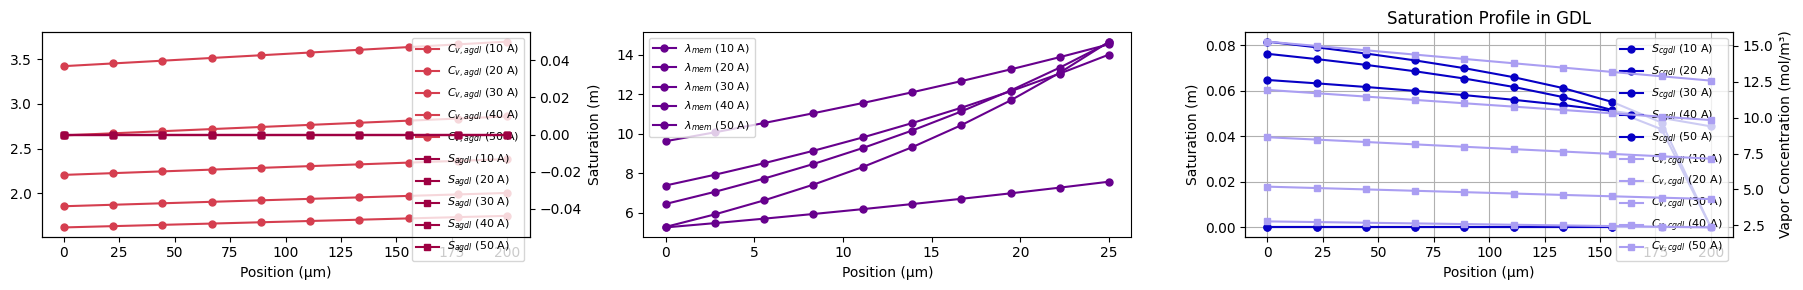

In [10]:
fig, axes = plt.subplots(nrows=1, ncols= 3, figsize=(18, 3))
ax0_2 = axes[0].twinx()
ax2_2 = axes[2].twinx()
x_gdl = np.linspace(0, parameters["Hgdl"]*1e6, 10)
x_mem = np.linspace(0, parameters["Hmem"]*1e6, 10)

for I_LOAD, sol in simulation_log.items():
    axes[0].plot(x_gdl, sol["Cv_agdl"], marker='o', markersize=5, color = "#d53e4f", label = f"$C_{{v, agdl}}$ ({I_LOAD} A)")
    ax0_2.plot(x_gdl, sol["s_agdl"], marker='s', markersize=5, color = "#9e0142", label = f"$S_{{agdl}}$ ({I_LOAD} A)")
    axes[1].plot(x_mem, sol["lambda_mem"], marker='o', markersize=5, color = "#67008d", label = rf"$\lambda_{{mem}}$ ({I_LOAD} A)")
    axes[2].plot(x_gdl, sol["s_cgdl"], marker='o', markersize=5, color = "#0700c5", label = f"$S_{{cgdl}}$ ({I_LOAD} A)")
    ax2_2.plot(x_gdl, sol["Cv_cgdl"], marker='s', markersize=5, color = "#aa9ef2", label = f"$C_{{v, cgdl}}$ ({I_LOAD} A)")

axes[0].set_xlabel('Position (µm)')
axes[1].set_xlabel('Position (µm)')
axes[2].set_xlabel('Position (µm)')
axes[2].set_ylabel('Saturation (m)')
axes[2].set_title('Saturation Profile in GDL')
axes[2].grid(True)
ax0_2.set_ylabel('Saturation (m)')
ax2_2.set_ylabel('Vapor Concentration (mol/m³)')

handles, labels = axes[0].get_legend_handles_labels()
handles2, labels2 = ax0_2.get_legend_handles_labels()
axes[0].legend(handles + handles2, labels + labels2, fontsize=8)
axes[1].legend(fontsize=8)
handles, labels = axes[2].get_legend_handles_labels()
handles2, labels2 = ax2_2.get_legend_handles_labels()
axes[2].legend(handles + handles2, labels + labels2, fontsize=8)
plt.tight_layout()
plt.show()